In [ ]:
!pip -q install -U kagglehub "datasets[audio]" transformers accelerate huggingface_hub \
  librosa soundfile scikit-learn pandas numpy matplotlib tqdm

!apt-get -qq update
!apt-get -qq install -y ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 27.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
import kagglehub, os, glob

path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset root:", path)

paths = glob.glob(os.path.join(path, "**", "*.wav"), recursive=True)
print("Found wav files:", len(paths))
print(paths[:3])

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Dataset root: /kaggle/input/ravdess-emotional-speech-audio
Found wav files: 2880
['/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav', '/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav']


In [ ]:
import re
import pandas as pd

EMO_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_filename(path):
    fname = os.path.basename(path)
    m = re.match(r"(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})\.wav$", fname)
    if not m:
        return None

    modality, channel, emo, intensity, statement, repetition, actor = m.groups()
    return {
        "path": path,
        "modality": modality,     # 03 audio-only
        "channel": channel,       # 01 speech
        "emotion": EMO_MAP.get(emo, None),
        "emotion_id": emo,
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor),
        "gender": "female" if int(actor) % 2 == 0 else "male",
    }

rows = []
for p in paths:
    rec = parse_ravdess_filename(p)
    if rec:
        rows.append(rec)

df = pd.DataFrame(rows)
print("Parsed:", len(df), "files")
print(df["emotion"].value_counts())
print("Actors:", df["actor"].nunique())
df.head()

Parsed: 2880 files
emotion
surprised    384
disgust      384
fearful      384
sad          384
calm         384
happy        384
angry        384
neutral      192
Name: count, dtype: int64
Actors: 24


,path,modality,channel,emotion,emotion_id,intensity,statement,repetition,actor,gender
0,/kaggle/input/ravdess-emotional-speech-audio/A...,03,01,surprised,08,01,01,01,2,female
1,/kaggle/input/ravdess-emotional-speech-audio/A...,03,01,neutral,01,01,01,01,2,female
2,/kaggle/input/ravdess-emotional-speech-audio/A...,03,01,disgust,07,02,01,02,2,female
3,/kaggle/input/ravdess-emotional-speech-audio/A...,03,01,disgust,07,01,01,02,2,female
4,/kaggle/input/ravdess-emotional-speech-audio/A...,03,01,neutral,01,01,02,01,2,female


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

LABELS = ["neutral","calm","happy","sad","angry","fearful","disgust","surprised"]
label2id = {l:i for i,l in enumerate(LABELS)}
id2label = {i:l for l,i in label2id.items()}

# Keep audio-only (03) and speech (01)
df = df[(df["modality"]=="03") & (df["channel"]=="01")].reset_index(drop=True)
df = df[df["emotion"].isin(LABELS)].reset_index(drop=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["actor"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(df_train), "Test:", len(df_test))
print("Train actors:", df_train["actor"].nunique(), "Test actors:", df_test["actor"].nunique())
print(df_train["emotion"].value_counts())

Train: 2160 Test: 720
Train actors: 18 Test actors: 6
emotion
surprised    288
disgust      288
fearful      288
sad          288
calm         288
happy        288
angry        288
neutral      144
Name: count, dtype: int64


In [ ]:
import librosa
import numpy as np
import os

def load_audio_16k_mono(path, max_s=6.0):
    tmp = "tmp_eval.wav"
    os.system(f'ffmpeg -y -i "{path}" -ac 1 -ar 16000 "{tmp}" -loglevel error')
    x, _ = librosa.load(tmp, sr=16000, mono=True)
    if max_s is not None:
        x = x[: int(max_s * 16000)]
    return x.astype(np.float32)

In [ ]:
import torch
import numpy as np
from transformers import AutoProcessor, AutoModelForAudioClassification

AUDEERING_ID = "audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor_aud = AutoProcessor.from_pretrained(AUDEERING_ID)
model_aud = AutoModelForAudioClassification.from_pretrained(AUDEERING_ID).to(device).eval()

print("num_labels:", model_aud.config.num_labels)
print("id2label:", model_aud.config.id2label)

@torch.no_grad()
def audeering_features(path, max_s=6.0):
    x = load_audio_16k_mono(path, max_s=max_s)
    inputs = processor_aud(x, sampling_rate=16000, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out = model_aud(**inputs)
    return out.logits.squeeze(0).detach().cpu().numpy().astype(np.float32)  # (3,)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/661M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/230 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
projector.bias             | MISSING    | 
projector.weight           | MISSING    | 
classifier.bias            | MISSING    | 
classifier.weight          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


num_labels: 3
id2label: {0: 'arousal', 1: 'dominance', 2: 'valence'}


In [ ]:
import torch.nn as nn
from pathlib import Path
from huggingface_hub import snapshot_download
from transformers import WhisperProcessor, WhisperForConditionalGeneration

LAION_REPO = "laion/Empathic-Insight-Voice-Small"
WHISPER_ID = "mkrausio/EmoWhisper-AnS-Small-v0.1"

laion_dir = Path(snapshot_download(repo_id=LAION_REPO))
whisper_proc = WhisperProcessor.from_pretrained(WHISPER_ID)
whisper_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_ID).to(device).eval()

WHISPER_SEQ_LEN = 1500
WHISPER_EMBED_DIM = 768
PROJ_DIM = 64
HIDDEN_DIMS = [64, 32, 16]
DROPOUTS = [0.0, 0.1, 0.1, 0.1]

class FullEmbeddingMLP(nn.Module):
    def __init__(self, seq_len, embed_dim, projection_dim, hidden_dims, dropout_rates):
        super().__init__()
        self.flatten = nn.Flatten()
        self.proj = nn.Linear(seq_len * embed_dim, projection_dim)
        layers = [nn.ReLU(), nn.Dropout(dropout_rates[0])]
        cur = projection_dim
        for i, h in enumerate(hidden_dims):
            layers += [nn.Linear(cur, h), nn.ReLU(), nn.Dropout(dropout_rates[i+1])]
            cur = h
        layers += [nn.Linear(cur, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(0)
        return self.mlp(self.proj(self.flatten(x)))

def find_pth(sub):
    hits = list(laion_dir.rglob(f"*{sub}*.pth"))
    if not hits:
        raise FileNotFoundError(f"Couldn't find .pth for: {sub}")
    return hits[0]

HEAD_ORDER = ["Anger","Fear","Sadness","Disgust","Astonishment","Elation","Amusement","Contentment","Relief","Arousal","Valence"]

def clean_state_dict(sd):
    # remove torch.compile prefix if present
    if any(k.startswith("_orig_mod.") for k in sd.keys()):
        sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
    return sd

laion_heads = {}
for name in HEAD_ORDER:
    pth = find_pth(name)
    head = FullEmbeddingMLP(WHISPER_SEQ_LEN, WHISPER_EMBED_DIM, PROJ_DIM, HIDDEN_DIMS, DROPOUTS)

    sd = torch.load(pth, map_location="cpu")
    sd = clean_state_dict(sd)

    head.load_state_dict(sd, strict=True)
    head.eval()
    laion_heads[name] = head
    print(f"{name:>12} <- {pth.name}")

@torch.no_grad()
def whisper_encoder_states(audio_16k):
    inputs = whisper_proc(audio_16k, sampling_rate=16000, return_tensors="pt")
    feats = inputs["input_features"].to(device)
    enc = whisper_model.model.encoder(feats).last_hidden_state  # [1, seq, dim]
    seq = enc.shape[1]
    if seq < WHISPER_SEQ_LEN:
        pad = torch.zeros((1, WHISPER_SEQ_LEN - seq, enc.shape[2]), device=enc.device, dtype=enc.dtype)
        enc = torch.cat([enc, pad], dim=1)
    else:
        enc = enc[:, :WHISPER_SEQ_LEN, :]
    return enc.squeeze(0).detach().cpu()

@torch.no_grad()
def laion_features(path, max_s=10.0):
    x = load_audio_16k_mono(path, max_s=max_s)
    enc = whisper_encoder_states(x)
    feats = [float(laion_heads[k](enc).squeeze().item()) for k in HEAD_ORDER]
    return np.array(feats, dtype=np.float32)  # (11,)

Fetching 61 files:   0%|          | 0/61 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

       Anger <- model_Anger_best.pth
        Fear <- model_Fear_best.pth
     Sadness <- model_Sadness_best.pth
     Disgust <- model_Disgust_best.pth
Astonishment <- model_Astonishment_Surprise_best.pth
     Elation <- model_Elation_best.pth
   Amusement <- model_Amusement_best.pth
 Contentment <- model_Contentment_best.pth
      Relief <- model_Relief_best.pth
     Arousal <- model_Arousal_best.pth
     Valence <- model_Valence_best.pth


Small train: 400 Small test: 160
Train label counts:
 emotion
sad          50
calm         50
surprised    50
neutral      50
happy        50
disgust      50
angry        50
fearful      50
Name: count, dtype: int64
Test label counts:
 emotion
calm         20
disgust      20
angry        20
neutral      20
fearful      20
sad          20
surprised    20
happy        20
Name: count, dtype: int64


100%|██████████| 160/160 [00:26<00:00,  6.11it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/met

X_train: (400, 3) X_test: (160, 3)
MODE: audeering
Accuracy: 0.2625
Macro F1: 0.20872000845020527

Classification report:
               precision    recall  f1-score   support

     neutral       0.12      0.15      0.13        20
        calm       0.35      0.40      0.37        20
       happy       0.29      0.20      0.24        20
         sad       0.00      0.00      0.00        20
       angry       1.00      0.05      0.10        20
     fearful       0.46      0.65      0.54        20
     disgust       0.19      0.65      0.29        20
   surprised       0.00      0.00      0.00        20

    accuracy                           0.26       160
   macro avg       0.30      0.26      0.21       160
weighted avg       0.30      0.26      0.21       160



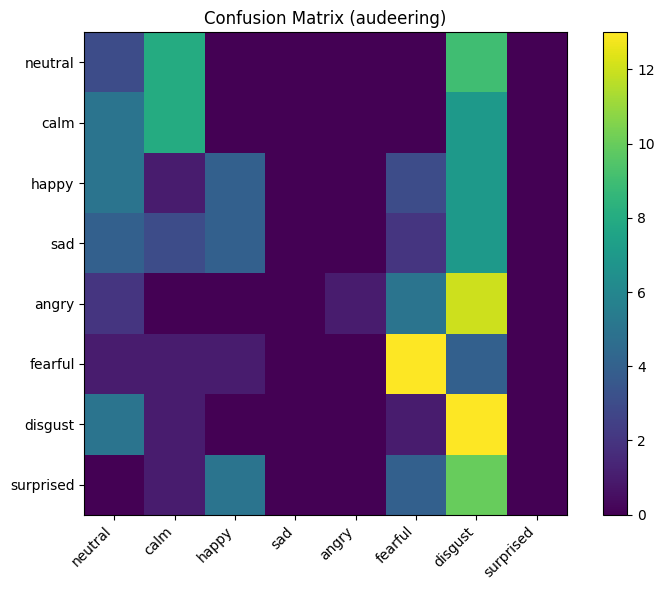

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

results = []

def sample_balanced(df_part, n_total, seed=42):
    labels = df_part["emotion"].unique().tolist()
    per_class = max(1, n_total // len(labels))

    chunks = []
    for lab in labels:
        sub = df_part[df_part["emotion"] == lab]
        k = min(per_class, len(sub))
        chunks.append(sub.sample(n=k, random_state=seed))

    out = pd.concat(chunks)
    # If we’re still short (because some class had fewer), top up randomly from the remaining rows
    if len(out) < n_total:
        remaining = df_part.loc[~df_part.index.isin(out.index)]
        extra = remaining.sample(
            n=min(n_total - len(out), len(remaining)),
            random_state=seed
        )
        out = pd.concat([out, extra])

    # Shuffle + trim + reset index
    out = out.sample(frac=1.0, random_state=seed).iloc[:n_total].reset_index(drop=True)
    return out


def build_xy(df_part, mode="both"):
    X, y = [], []
    for p, emo in tqdm(zip(df_part["path"], df_part["emotion"]), total=len(df_part)):
        if mode == "audeering":
            feats = audeering_features(p)
        elif mode == "laion":
            feats = laion_features(p)
        elif mode == "both":
            feats = np.concatenate([audeering_features(p), laion_features(p)], axis=0)
        else:
            raise ValueError("mode must be: audeering / laion / both")

        X.append(feats)
        y.append(label2id[emo])

    return np.stack(X), np.array(y, dtype=np.int64)


# ---- pick a small balanced subset for fast experiments ----
N_TRAIN = 400
N_TEST  = 160

df_train_small = sample_balanced(df_train, N_TRAIN, seed=42)
df_test_small  = sample_balanced(df_test,  N_TEST,  seed=43)

print("Small train:", len(df_train_small), "Small test:", len(df_test_small))
print("Train label counts:\n", df_train_small["emotion"].value_counts())
print("Test label counts:\n", df_test_small["emotion"].value_counts())


# ---- choose features: "audeering" / "laion" / "both" ----
MODE = "audeering"

X_train, y_train = build_xy(df_train_small, mode=MODE)
X_test,  y_test  = build_xy(df_test_small,  mode=MODE)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


# ---- baseline classifier ----
clf = LogisticRegression(max_iter=5000, n_jobs=-1)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
f1m = f1_score(y_test, pred, average="macro")
results.append({
    "Model": MODE,
    "Feature_Dim": X_train.shape[1],
    "Accuracy": acc,
    "Macro_F1": f1m
})
print("MODE:", MODE)
print("Accuracy:", acc)
print("Macro F1:", f1m)
print("\nClassification report:\n", classification_report(y_test, pred, target_names=LABELS))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix ({MODE})")
plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
plt.yticks(range(len(LABELS)), LABELS)
plt.colorbar()
plt.tight_layout()
plt.show()

Small train: 400 Small test: 160
Train label counts:
 emotion
sad          50
calm         50
surprised    50
neutral      50
happy        50
disgust      50
angry        50
fearful      50
Name: count, dtype: int64
Test label counts:
 emotion
calm         20
disgust      20
angry        20
neutral      20
fearful      20
sad          20
surprised    20
happy        20
Name: count, dtype: int64


100%|██████████| 160/160 [01:23<00:00,  1.92it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


X_train: (400, 11) X_test: (160, 11)
MODE: laion
Accuracy: 0.4
Macro F1: 0.3655759540358656

Classification report:
               precision    recall  f1-score   support

     neutral       0.33      0.80      0.46        20
        calm       0.36      0.25      0.29        20
       happy       0.22      0.10      0.14        20
         sad       0.38      0.30      0.33        20
       angry       0.50      0.55      0.52        20
     fearful       0.52      0.55      0.54        20
     disgust       0.17      0.05      0.08        20
   surprised       0.52      0.60      0.56        20

    accuracy                           0.40       160
   macro avg       0.37      0.40      0.37       160
weighted avg       0.37      0.40      0.37       160



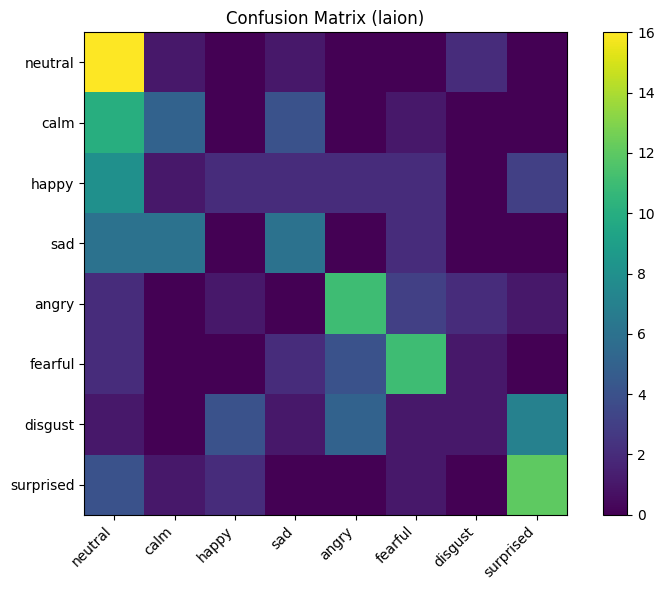

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


def sample_balanced(df_part, n_total, seed=42):
    labels = df_part["emotion"].unique().tolist()
    per_class = max(1, n_total // len(labels))

    chunks = []
    for lab in labels:
        sub = df_part[df_part["emotion"] == lab]
        k = min(per_class, len(sub))
        chunks.append(sub.sample(n=k, random_state=seed))

    out = pd.concat(chunks)
    # If we’re still short (because some class had fewer), top up randomly from the remaining rows
    if len(out) < n_total:
        remaining = df_part.loc[~df_part.index.isin(out.index)]
        extra = remaining.sample(
            n=min(n_total - len(out), len(remaining)),
            random_state=seed
        )
        out = pd.concat([out, extra])

    # Shuffle + trim + reset index
    out = out.sample(frac=1.0, random_state=seed).iloc[:n_total].reset_index(drop=True)
    return out


def build_xy(df_part, mode="both"):
    X, y = [], []
    for p, emo in tqdm(zip(df_part["path"], df_part["emotion"]), total=len(df_part)):
        if mode == "audeering":
            feats = audeering_features(p)
        elif mode == "laion":
            feats = laion_features(p)
        elif mode == "both":
            feats = np.concatenate([audeering_features(p), laion_features(p)], axis=0)
        else:
            raise ValueError("mode must be: audeering / laion / both")

        X.append(feats)
        y.append(label2id[emo])

    return np.stack(X), np.array(y, dtype=np.int64)


# ---- pick a small balanced subset for fast experiments ----
N_TRAIN = 400
N_TEST  = 160

df_train_small = sample_balanced(df_train, N_TRAIN, seed=42)
df_test_small  = sample_balanced(df_test,  N_TEST,  seed=43)

print("Small train:", len(df_train_small), "Small test:", len(df_test_small))
print("Train label counts:\n", df_train_small["emotion"].value_counts())
print("Test label counts:\n", df_test_small["emotion"].value_counts())


# ---- choose features: "audeering" / "laion" / "both" ----
MODE = "laion"

X_train, y_train = build_xy(df_train_small, mode=MODE)
X_test,  y_test  = build_xy(df_test_small,  mode=MODE)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


# ---- baseline classifier ----
clf = LogisticRegression(max_iter=5000, n_jobs=-1)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
f1m = f1_score(y_test, pred, average="macro")
results.append({
    "Model": MODE,
    "Feature_Dim": X_train.shape[1],
    "Accuracy": acc,
    "Macro_F1": f1m
})
print("MODE:", MODE)
print("Accuracy:", acc)
print("Macro F1:", f1m)
print("\nClassification report:\n", classification_report(y_test, pred, target_names=LABELS))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix ({MODE})")
plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
plt.yticks(range(len(LABELS)), LABELS)
plt.colorbar()
plt.tight_layout()
plt.show()

Small train: 400 Small test: 160
Train label counts:
 emotion
sad          50
calm         50
surprised    50
neutral      50
happy        50
disgust      50
angry        50
fearful      50
Name: count, dtype: int64
Test label counts:
 emotion
calm         20
disgust      20
angry        20
neutral      20
fearful      20
sad          20
surprised    20
happy        20
Name: count, dtype: int64


100%|██████████| 160/160 [01:43<00:00,  1.55it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


X_train: (400, 14) X_test: (160, 14)
MODE: both
Accuracy: 0.4
Macro F1: 0.3655759540358656

Classification report:
               precision    recall  f1-score   support

     neutral       0.33      0.80      0.46        20
        calm       0.36      0.25      0.29        20
       happy       0.22      0.10      0.14        20
         sad       0.38      0.30      0.33        20
       angry       0.50      0.55      0.52        20
     fearful       0.52      0.55      0.54        20
     disgust       0.17      0.05      0.08        20
   surprised       0.52      0.60      0.56        20

    accuracy                           0.40       160
   macro avg       0.37      0.40      0.37       160
weighted avg       0.37      0.40      0.37       160



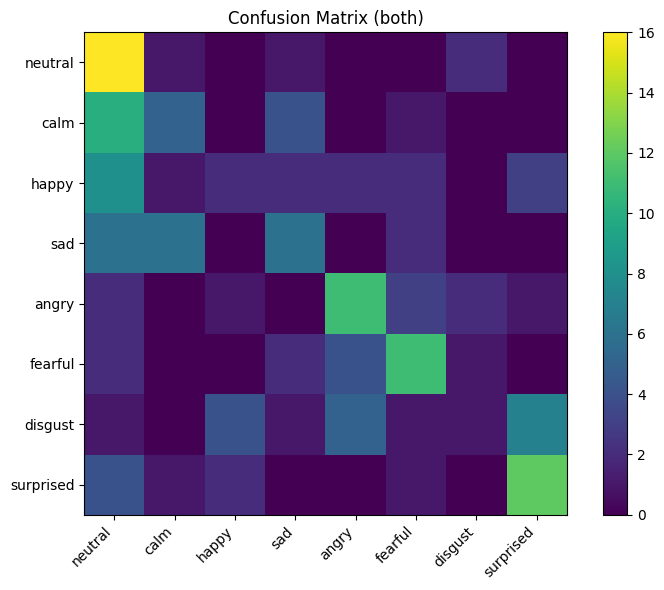

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


def sample_balanced(df_part, n_total, seed=42):
    labels = df_part["emotion"].unique().tolist()
    per_class = max(1, n_total // len(labels))

    chunks = []
    for lab in labels:
        sub = df_part[df_part["emotion"] == lab]
        k = min(per_class, len(sub))
        chunks.append(sub.sample(n=k, random_state=seed))

    out = pd.concat(chunks)
    # If we’re still short (because some class had fewer), top up randomly from the remaining rows
    if len(out) < n_total:
        remaining = df_part.loc[~df_part.index.isin(out.index)]
        extra = remaining.sample(
            n=min(n_total - len(out), len(remaining)),
            random_state=seed
        )
        out = pd.concat([out, extra])

    # Shuffle + trim + reset index
    out = out.sample(frac=1.0, random_state=seed).iloc[:n_total].reset_index(drop=True)
    return out


def build_xy(df_part, mode="both"):
    X, y = [], []
    for p, emo in tqdm(zip(df_part["path"], df_part["emotion"]), total=len(df_part)):
        if mode == "audeering":
            feats = audeering_features(p)
        elif mode == "laion":
            feats = laion_features(p)
        elif mode == "both":
            feats = np.concatenate([audeering_features(p), laion_features(p)], axis=0)
        else:
            raise ValueError("mode must be: audeering / laion / both")

        X.append(feats)
        y.append(label2id[emo])

    return np.stack(X), np.array(y, dtype=np.int64)


# ---- pick a small balanced subset for fast experiments ----
N_TRAIN = 400
N_TEST  = 160

df_train_small = sample_balanced(df_train, N_TRAIN, seed=42)
df_test_small  = sample_balanced(df_test,  N_TEST,  seed=43)

print("Small train:", len(df_train_small), "Small test:", len(df_test_small))
print("Train label counts:\n", df_train_small["emotion"].value_counts())
print("Test label counts:\n", df_test_small["emotion"].value_counts())


# ---- choose features: "audeering" / "laion" / "both" ----
MODE = "both"

X_train, y_train = build_xy(df_train_small, mode=MODE)
X_test,  y_test  = build_xy(df_test_small,  mode=MODE)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


# ---- baseline classifier ----
clf = LogisticRegression(max_iter=5000, n_jobs=-1)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
f1m = f1_score(y_test, pred, average="macro")
results.append({
    "Model": MODE,
    "Feature_Dim": X_train.shape[1],
    "Accuracy": acc,
    "Macro_F1": f1m
})
print("MODE:", MODE)
print("Accuracy:", acc)
print("Macro F1:", f1m)
print("\nClassification report:\n", classification_report(y_test, pred, target_names=LABELS))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix ({MODE})")
plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
plt.yticks(range(len(LABELS)), LABELS)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results

df_display = df_results.copy()
df_display["Accuracy (%)"] = (df_display["Accuracy"] * 100).round(2)
df_display["Macro F1 (%)"] = (df_display["Macro_F1"] * 100).round(2)

df_display = df_display[["Model", "Feature_Dim", "Accuracy (%)", "Macro F1 (%)"]]
df_display

,Model,Feature_Dim,Accuracy (%),Macro F1 (%)
0,audeering,3,26.25,20.87
1,laion,11,40.00,36.56
2,both,14,40.00,36.56
